# Water tank temperature measurements analysis

In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [80]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *
from usnm2p.fileops import *

### Inputs

In [81]:
dataroot = '/Users/tlemaire/Documents/data/US_thermal_experiments'
experiment = '20260904_tank'
datadir = os.path.join(dataroot, experiment)

# Root directory for output figures
figsdir = os.path.join(dataroot, 'figs')
if not os.path.exists(figsdir):
    os.makedirs(figsdir)
logger.info(f'output figures directory: "{figsdir}"')

# Figures dictionary
figs = {}

 2026/09/16 15:59:14: output figures directory: "/Users/tlemaire/Documents/data/US_thermal_experiments/figs"


### Load data

 2026/09/16 15:59:14: loading info from "/Users/tlemaire/Documents/data/US_thermal_experiments/20260904_tank" recording
 2026/09/16 15:59:14: getting sample rate from info.rhd header
 2026/09/16 15:59:14: Intan RHD version: 1.5
 2026/09/16 15:59:14: Intan RHD sample rate: 20000.0 Hz
 2026/09/16 15:59:14: Intan RHD board mode: 0
 2026/09/16 15:59:14: getting sample count and analog channel count from file sizes
 2026/09/16 15:59:14: sample count: 268600320, analog channel count: 1
 2026/09/16 15:59:14: loading analogin.dat as memmap
 2026/09/16 15:59:14: downsampling channel 0 from 20000.0 Hz to 119.760 Hz
 2026/09/16 15:59:16: converting downsampled ADC vector to volts
 2026/09/16 15:59:16: generating downsampled time vector
 2026/09/16 15:59:16: converting Osensa probe voltage to °C
 2026/09/16 15:59:16: Lowpass filtering temperature trace at 30 Hz
 2026/09/16 15:59:16: plotting longitudinal temperature recording at 3.992 Hz
 2026/09/16 15:59:16: loading digitalin.dat as memmap
 2026/

T (°C)                  timestamp  x (mm)  y (mm)  z (mm)  \
trial time (s)                                                                  
0     -0.491675  26.761211 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.483325  26.763724 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.474975  26.762011 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.466625  26.759506 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.458275  26.761153 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
...                    ...                        ...     ...     ...     ...   
3023   3.240775  22.085236 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.249125  22.083559 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.257475  22.084416 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.265825  22.085895 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.274175  22.085344 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   

                 Fdrive (MHz)  P (MPa)   Vpp (V)  tstim (s)  PRF (Hz)  DC (%)  \
trial time (s)                                                                  
0     -0.491675         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.483325         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.474975         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.466625         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.458275         2.095      0.0  0.000000        0.2     100.0    80.0   
...                       ...      ...       ...        ...       ...     ...   
3023   3.240775         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.249125         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.257475         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.265825         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.274175         2.095      0.8  0.257133        0.2     100.0    80.0   

                 elapsed time (s)  I_SPPA (W/cm2)  I_SPTA (W/cm2)  
trial time (s)                                                     
0     -0.491675          0.000000            0.00            0.00  
      -0.483325          0.000000            0.00            0.00  
      -0.474975          0.000000            0.00            0.00  
      -0.466625          0.000000            0.00            0.00  
      -0.458275          0.000000            0.00            0.00  
...                           ...             ...             ...  
3023   3.240775      12522.377839           19.78           15.83  
       3.249125      12522.377839           19.78           15.83  
       3.257475      12522.377839           19.78           15.83  
       3.265825      12522.377839           19.78           15.83  
       3.274175      12522.377839           19.78           15.83  

[1366848 rows x 14 columns]

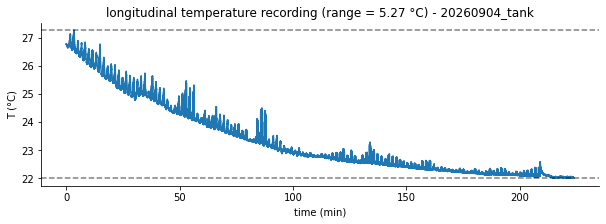

In [82]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadir, plot=True, figdict=figs)

# Compute ISPPA and ISPTA columns
data[Label.ISPPA] = pressure_to_intensity(data[Label.P] / PA_TO_MPA) / M2_TO_CM2  # W/cm2
data[Label.ISPTA] = data[Label.ISPPA] * data[Label.DC] / 1e2
for k in [Label.ISPPA, Label.ISPTA]:
    data[k] = data[k].round(2)

# Extract experimental duty cycle
DC = get_singleton(data, Label.DC)

logger.info('processed experiment data:')
data

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [83]:
# Apply trial-by-trial linear detrending to the temperature data
logger.info('detrending temperature traces trial-by-trial')
data[f'detrended {TEMP_KEY}'] = (
    data
    .groupby('trial')
    [TEMP_KEY]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[REL_TEMP_KEY] = (
    data
    .groupby('trial')
    [f'detrended {TEMP_KEY}']
    .transform(compute_deltaT)
)

data

 2026/09/16 15:59:20: detrending temperature traces trial-by-trial
 2026/09/16 15:59:24: computing trial-by-trial relative temperature change


T (°C)                  timestamp  x (mm)  y (mm)  z (mm)  \
trial time (s)                                                                  
0     -0.491675  26.761211 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.483325  26.763724 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.474975  26.762011 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.466625  26.759506 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
      -0.458275  26.761153 2026-09-04 11:54:33.603206    -3.0     0.5     1.0   
...                    ...                        ...     ...     ...     ...   
3023   3.240775  22.085236 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.249125  22.083559 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.257475  22.084416 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.265825  22.085895 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   
       3.274175  22.085344 2026-09-04 15:23:15.981045    -3.0     0.5     6.0   

                 Fdrive (MHz)  P (MPa)   Vpp (V)  tstim (s)  PRF (Hz)  DC (%)  \
trial time (s)                                                                  
0     -0.491675         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.483325         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.474975         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.466625         2.095      0.0  0.000000        0.2     100.0    80.0   
      -0.458275         2.095      0.0  0.000000        0.2     100.0    80.0   
...                       ...      ...       ...        ...       ...     ...   
3023   3.240775         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.249125         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.257475         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.265825         2.095      0.8  0.257133        0.2     100.0    80.0   
       3.274175         2.095      0.8  0.257133        0.2     100.0    80.0   

                 elapsed time (s)  I_SPPA (W/cm2)  I_SPTA (W/cm2)  \
trial time (s)                                                      
0     -0.491675          0.000000            0.00            0.00   
      -0.483325          0.000000            0.00            0.00   
      -0.474975          0.000000            0.00            0.00   
      -0.466625          0.000000            0.00            0.00   
      -0.458275          0.000000            0.00            0.00   
...                           ...             ...             ...   
3023   3.240775      12522.377839           19.78           15.83   
       3.249125      12522.377839           19.78           15.83   
       3.257475      12522.377839           19.78           15.83   
       3.265825      12522.377839           19.78           15.83   
       3.274175      12522.377839           19.78           15.83   

                 detrended T (°C)   ΔT (°C)  
trial time (s)                               
0     -0.491675         26.750429  0.001455  
      -0.483325         26.753003  0.004029  
      -0.474975         26.751352  0.002378  
      -0.466625         26.748909 -0.000065  
      -0.458275         26.750618  0.001644  
...                           ...       ...  
3023   3.240775         22.086279 -0.001843  
       3.249125         22.084606 -0.003517  
       3.257475         22.085467 -0.002655  
       3.265825         22.086950 -0.001173  
       3.274175         22.086402 -0.001720  

[1366848 rows x 16 columns]

### Plot stim-evoked temperature traces across XYZ grid, color-coded by pressure

 2026/09/16 15:59:29: plotting stimulus-evoked temperature traces for y = -0.5 mm
 2026/09/16 15:59:56: plotting stimulus-evoked temperature traces for y = 0.0 mm
 2026/09/16 16:00:22: plotting stimulus-evoked temperature traces for y = 0.5 mm


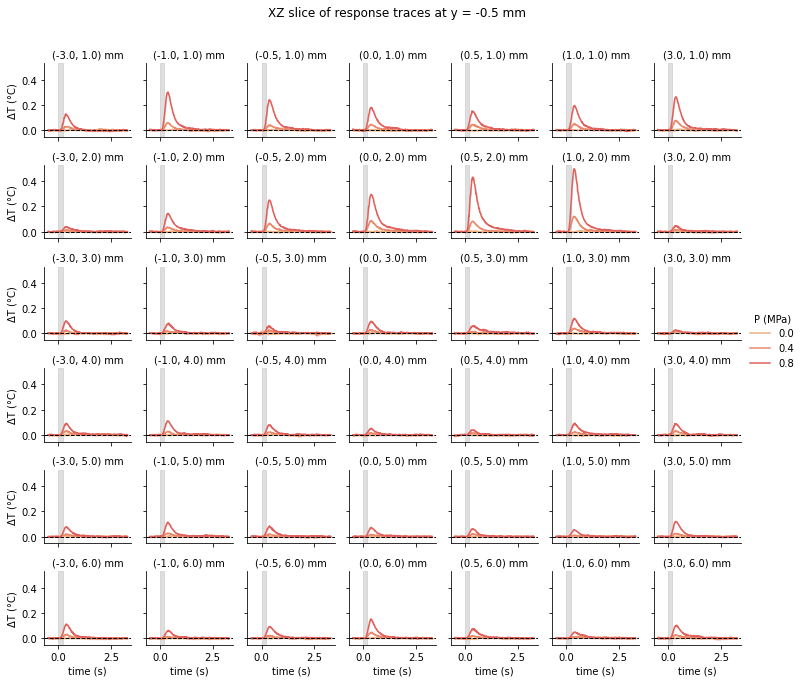

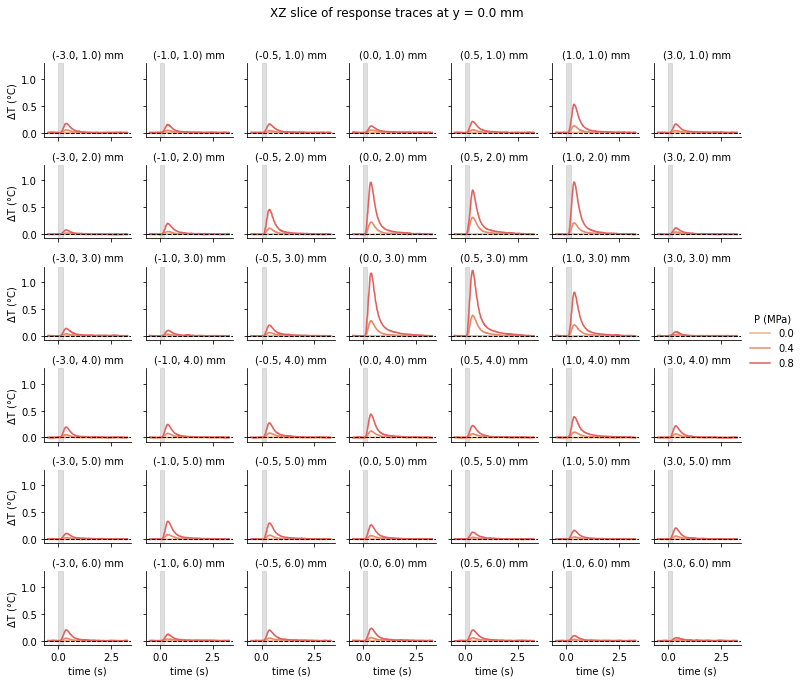

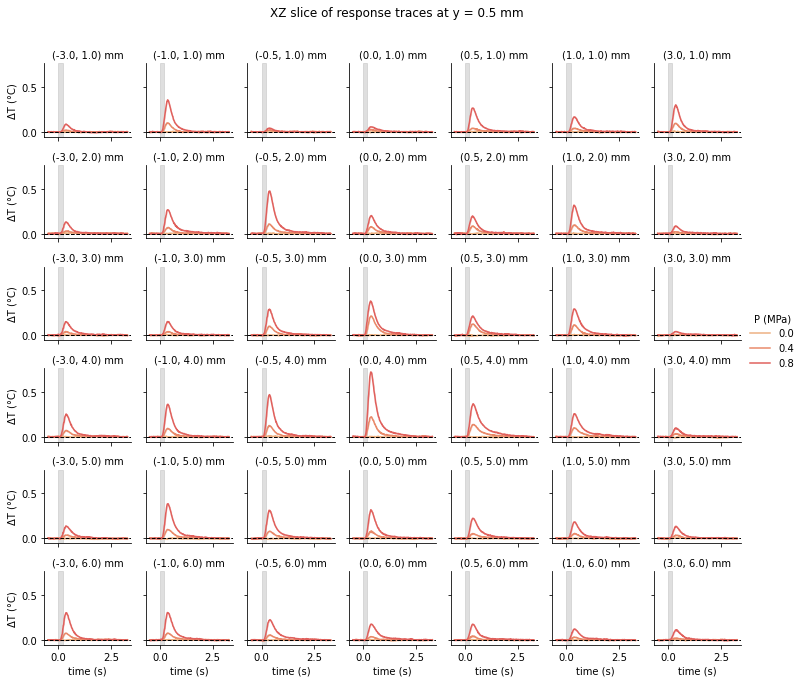

In [84]:
# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
hue = Label.P
for y, gdata in data.groupby(Y_KEY):
    logger.info(f'plotting stimulus-evoked temperature traces for y = {y:.1f} mm')
    figkey = f'XZ slice of response traces at y = {y:.1f} mm'
    g = sns.FacetGrid(
        data=gdata.reset_index(),
        col=X_KEY,
        row=Z_KEY,
        height=1.5,
    )
    g.set_titles(template='({col_name:.1f}, {row_name:.1f}) mm')
    g.map_dataframe(
        plot_evoked_thermal_response,
        y=REL_TEMP_KEY, 
        errorbar='se',
        hue=hue,
        palette='flare',
    )
    g.add_legend(title=hue)
    figs[figkey] = g.figure
    figs[figkey].suptitle(figkey, y=1.05)

### Aggregate traces across trials for each condition 

In [85]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/16 16:01:15: computing trial-average data by ['x (mm)', 'y (mm)', 'z (mm)', 'P (MPa)', 'I_SPPA (W/cm2)', 'I_SPTA (W/cm2)']


T (°C)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)               
-3.0   -0.5   1.0    0.0     0.00           0.00           -0.491675  25.470824   
                                                           -0.483325  25.469734   
                                                           -0.474975  25.468912   
                                                           -0.466625  25.469246   
                                                           -0.458275  25.469799   
...                                                                         ...   
 3.0    0.5   6.0    0.8     19.78          15.83           3.240775  22.122608   
                                                            3.249125  22.122073   
                                                            3.257475  22.121733   
                                                            3.265825  22.123037   
                                                            3.274175  22.125579   

                                                                       Vpp (V)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
-3.0   -0.5   1.0    0.0     0.00           0.00           -0.491675  0.000000   
                                                           -0.483325  0.000000   
                                                           -0.474975  0.000000   
                                                           -0.466625  0.000000   
                                                           -0.458275  0.000000   
...                                                                        ...   
 3.0    0.5   6.0    0.8     19.78          15.83           3.240775  0.257133   
                                                            3.249125  0.257133   
                                                            3.257475  0.257133   
                                                            3.265825  0.257133   
                                                            3.274175  0.257133   

                                                                      detrended T (°C)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)                      
-3.0   -0.5   1.0    0.0     0.00           0.00           -0.491675         25.442312   
                                                           -0.483325         25.441385   
                                                           -0.474975         25.440727   
                                                           -0.466625         25.441224   
                                                           -0.458275         25.441940   
...                                                                                ...   
 3.0    0.5   6.0    0.8     19.78          15.83           3.240775         22.118839   
                                                            3.249125         22.118291   
                                                            3.257475         22.117936   
                                                            3.265825         22.119226   
                                                            3.274175         22.121755   

                                                                       ΔT (°C)  \
x (mm) y (mm) z (mm) P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
-3.0   -0.5   1.0    0.0     0.00           0.00           -0.491675  0.000702   
                                                           -0.483325 -0.000225   
                                                           -0.474975 -0.000884   
                                                           -0.466625 -0.000386   
                                                           -0.458275  0.000329   
...                                                                        ...   
 3.0    0.5   6.0    0.8     19.78          15.83           3.240775 -0.001669   
                 

### Fit double exponential to trial-average profiles

 2026/09/16 16:01:17: fitting double exponential to trial-averaged temperature traces
 2026/09/16 16:01:20: constructing fitted double exponential traces
 2026/09/16 16:01:20: plotting t0 distribution
 2026/09/16 16:01:20: plotting peak distribution
 2026/09/16 16:01:21: plotting tau_rise distribution
 2026/09/16 16:01:21: plotting tau_decay distribution
 2026/09/16 16:01:21: plotting offset distribution


Text(0.5, 1.05, 'distribution of double exponential fit parameters')

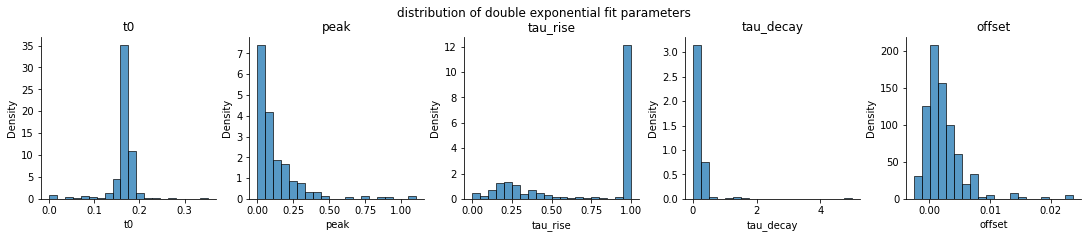

In [86]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = [k for k in aggdata.index.names if k != TIME_KEY]
groups = aggdata.groupby(gby)[REL_TEMP_KEY]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {REL_TEMP_KEY}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(TIME_KEY).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(TIME_KEY))
)

naxes = len(fits.columns)
figkey = 'distribution of double exponential fit parameters'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(3 * naxes, 3), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.histplot(
        fits[k],
        ax=ax,
        bins=20,
        stat='density',
    )
    ax.set_title(k)
    sns.despine(ax=ax)
figs[figkey].suptitle(figkey, y=1.05)

### Plot trial-averaged stim-evoked temperature traces and fitted double exponential traces

 2026/09/16 16:01:22: plotting trial-averaged stimulus-evoked temperature traces with fits for y = -0.5 mm
 2026/09/16 16:01:33: plotting trial-averaged stimulus-evoked temperature traces with fits for y = 0.0 mm
 2026/09/16 16:01:44: plotting trial-averaged stimulus-evoked temperature traces with fits for y = 0.5 mm


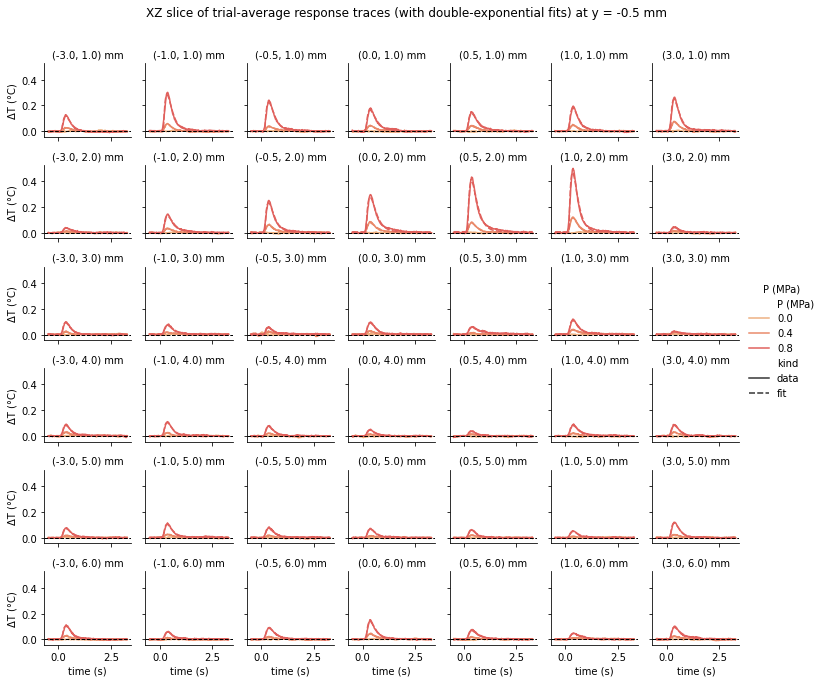

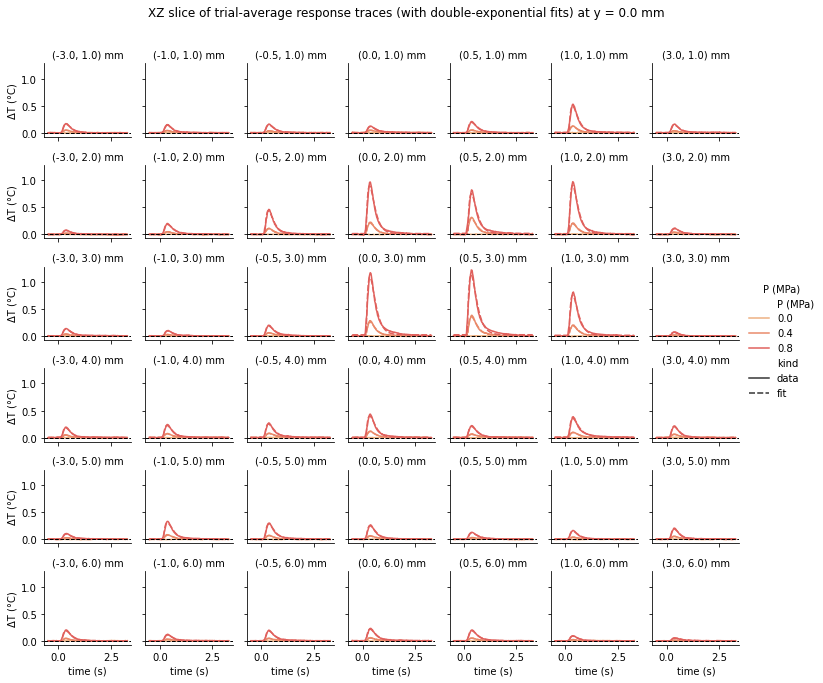

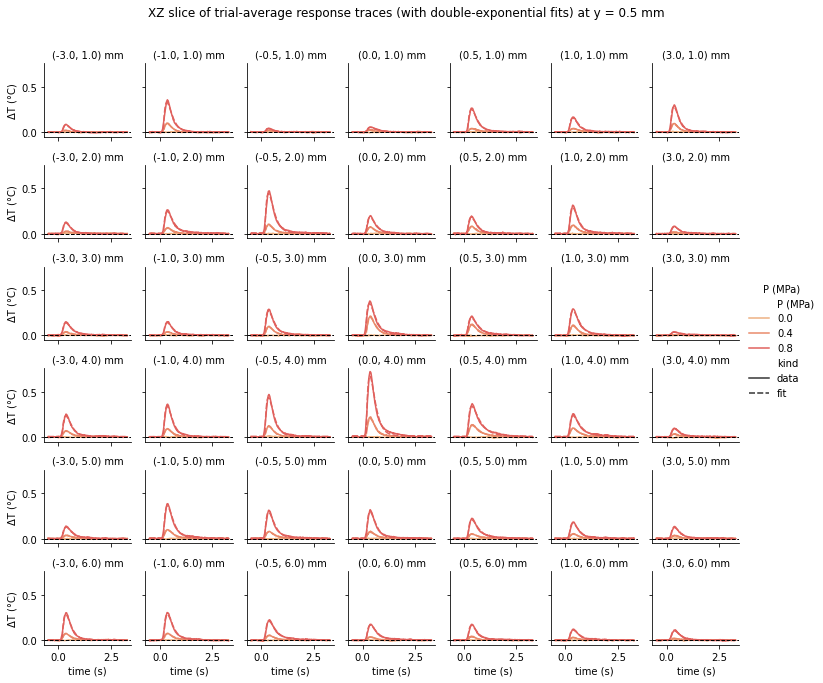

In [87]:
# Melt data by data/fit kind for plotting
ymap = {
    REL_TEMP_KEY: 'data',
    f'fitted {REL_TEMP_KEY}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure, with data and fitted traces distinguished by line style
hue = Label.P
for y, gdata in melted_data.groupby(Y_KEY):
    logger.info(f'plotting trial-averaged stimulus-evoked temperature traces with fits for y = {y:.1f} mm')
    figkey = f'XZ slice of trial-average response traces (with double-exponential fits) at y = {y:.1f} mm'
    g = sns.FacetGrid(
        data=gdata.reset_index(),
        col=X_KEY,
        row=Z_KEY,
        height=1.5,
    )
    g.set_titles(template='({col_name:.1f}, {row_name:.1f}) mm')
    g.map_dataframe(
        plot_evoked_thermal_response,
        y=REL_TEMP_KEY, 
        hue=hue,
        palette='flare',
        style='kind',
    )
    g.add_legend(title=hue)
    figs[figkey] = g.figure
    figs[figkey].suptitle(figkey, y=1.05)

### Compute and plot max-evoked temperature change for each location and pressure

 2026/09/16 16:02:05: computing max-evoked temperature change for each condition and trial
 2026/09/16 16:02:06: computing average max-evoked temperature change for each condition
 2026/09/16 16:02:06: plotting max ΔT (°C) XZ heatmap for y = -0.5 mm, P = 0.0 MPa
 2026/09/16 16:02:06: plotting max ΔT (°C) XZ heatmap for y = 0.0 mm, P = 0.0 MPa
 2026/09/16 16:02:06: plotting max ΔT (°C) XZ heatmap for y = 0.5 mm, P = 0.0 MPa
 2026/09/16 16:02:06: plotting max ΔT (°C) XZ heatmap for y = -0.5 mm, P = 0.4 MPa
 2026/09/16 16:02:07: plotting max ΔT (°C) XZ heatmap for y = 0.0 mm, P = 0.4 MPa
 2026/09/16 16:02:07: plotting max ΔT (°C) XZ heatmap for y = 0.5 mm, P = 0.4 MPa
 2026/09/16 16:02:07: plotting max ΔT (°C) XZ heatmap for y = -0.5 mm, P = 0.8 MPa
 2026/09/16 16:02:07: plotting max ΔT (°C) XZ heatmap for y = 0.0 mm, P = 0.8 MPa
 2026/09/16 16:02:07: plotting max ΔT (°C) XZ heatmap for y = 0.5 mm, P = 0.8 MPa


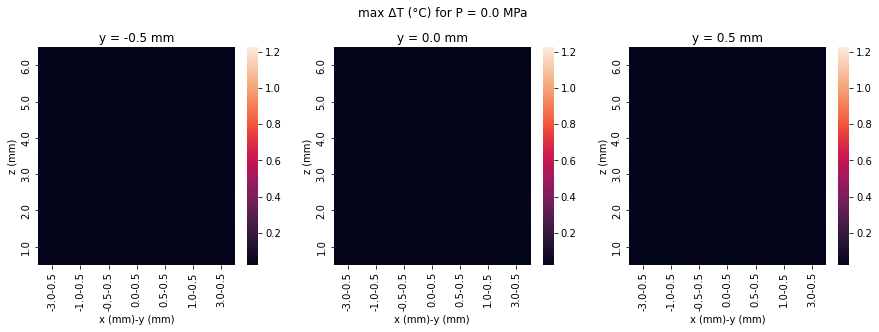

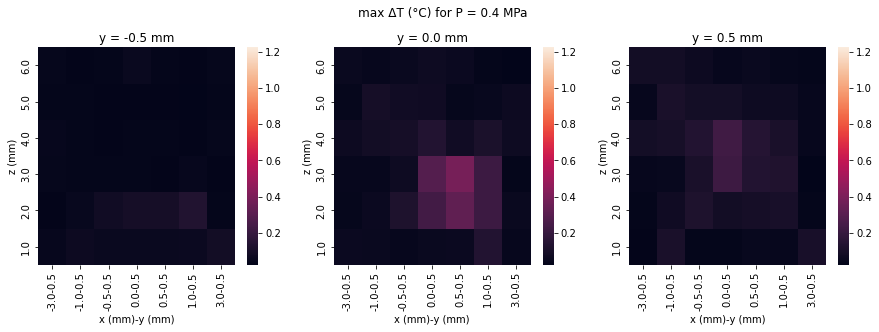

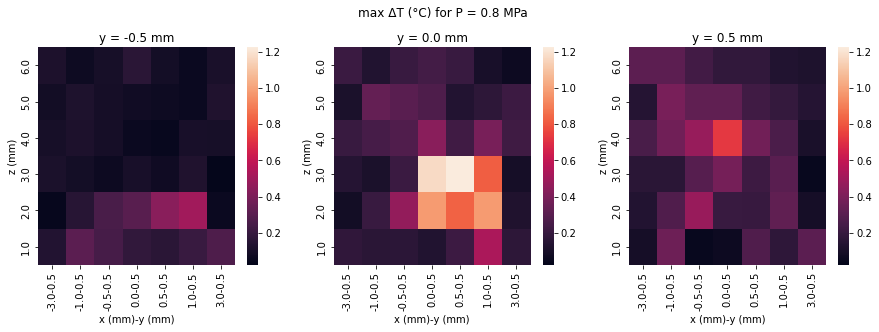

In [88]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(data)
logger.info('computing max-evoked temperature change for each condition and trial')
max_evoked_change = (
    data
    .groupby([*cond_keys, 'trial'])
    [REL_TEMP_KEY]
    .max()
    .rename(MAX_REL_TEMP_KEY)
)
max_evoked_change

logger.info('computing average max-evoked temperature change for each condition')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

# Plot XZ heatmaps of max-evoked temperature change for each pressure and y position
vmin, vmax = agg_max_evoked_change.min(), agg_max_evoked_change.max()
gby = [Y_KEY, Label.P]
for P, gdata in agg_max_evoked_change.groupby(Label.P):
    naxes = len(gdata.index.get_level_values(Y_KEY).unique())
    singledims = [k for k in gdata.index.names if len(gdata.index.get_level_values(k).unique()) == 1]
    figkey = f'{MAX_REL_TEMP_KEY} for P = {P:.1f} MPa'
    figs[figkey], axes = plt.subplots(1, naxes, figsize=(5 * naxes, 4), sharex=True)
    figs[figkey].suptitle(figkey, y=1.02)
    for (y, gdata2), ax in zip(gdata.droplevel(singledims).groupby(Y_KEY), axes):
        logger.info(f'plotting {MAX_REL_TEMP_KEY} XZ heatmap for y = {y:.1f} mm, P = {P:.1f} MPa')
        ax.set_title(f'y = {y:.1f} mm')
        sns.heatmap(
            gdata2.unstack().T,
            ax=ax,
            vmin=vmin,
            vmax=vmax
        )
        ax.invert_yaxis()

### Plot ISPTA-dependence of evoked temperature change at focus

 2026/09/16 16:02:09: focus identified at XYZ = (0.5, 0.0, 3.0) mm, max ΔT (°C) = 1.23
 2026/09/16 16:02:09: plotting ISPTA-dependent evoked temperature change traces
 2026/09/16 16:02:09: performing least-square linear fit on max_ΔT vs ISPTA
 2026/09/16 16:02:09: least-square linear fit: slope = 0.079 °C/(W/cm²), R² = 0.99
 2026/09/16 16:02:09: plotting ISPTA-dependence of max-evoked temperature change at focus
 2026/09/16 16:02:09: predicted max-evoked temperature change at 15.83 W/cm²: 1.244 °C
 2026/09/16 16:02:09: max ΔT predicted at ISPTA = 15.83 W/cm2 at focus: 1.24 °C


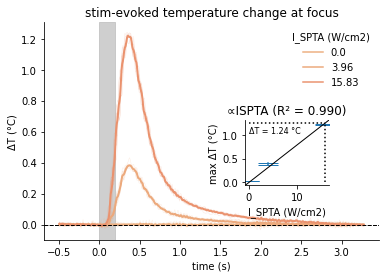

In [89]:
# Compute target ISPTA value corresponding to the reference pressure P_REF and experimental duty cycle DC
target_ISPPA = pressure_to_intensity(P_REF / PA_TO_MPA) / M2_TO_CM2  # W/cm2
target_ISPTA = np.round(target_ISPPA * DC / 1e2, 2)  # W/cm2

# Identify focus from trial-average max evoked temperature change at max pressure
maxP = data[Label.P].max()
focus_xyz = agg_max_evoked_change.loc[pd.IndexSlice[:, :, :, maxP]].idxmax()[:3]
focus_agg_max_evoked_change = agg_max_evoked_change.loc[
    pd.IndexSlice[focus_xyz[0], focus_xyz[1], focus_xyz[2], maxP, :, :]].values[0]
logger.info(f'focus identified at XYZ = {focus_xyz} mm, {MAX_REL_TEMP_KEY} = {focus_agg_max_evoked_change:.2f}')

# Extract stats and data for the focus condition
focus_data, focus_max_evoked_change = select_subset(
    data, max_evoked_change, focus_xyz)

# Plot ISPTA dependence of temperature change at focus, with quadratic fit and R² value
figkey = 'stim-evoked temperature change at focus'
figs[figkey], max_ΔT_pred_at_target_ISPTA_at_focus = plot_ispta_dependence(
    focus_data, focus_max_evoked_change, title=figkey, Itarget=target_ISPTA)
logger.info(f'max ΔT predicted at ISPTA = {target_ISPTA:.2f} W/cm2 at focus: {max_ΔT_pred_at_target_ISPTA_at_focus:.2f} °C')

### Save figures

In [90]:
save_figs_book(figsdir, figs, suffix=experiment)

 2026/09/16 16:02:10: saving figures in /Users/tlemaire/Documents/data/US_thermal_experiments/figs/2026.09.16/figs_20260904_tank.pdf:


100%|██████████| 12/12 [00:25<00:00,  2.09s/it]
